<a href="https://colab.research.google.com/github/SOURAV143-BIT/CUSTOMER-CHURN-PREDICTION-USING-KERAS-NEURAL-NETWORKS/blob/main/CUSTOMER_CHURN_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Customer churn, in simple terms means that the customer has stopped doing business with the company
and this is a common problem when it comes to telecom industries. To avoid this, companies use predictive
analysis to gauge the factors responsible for a customer to leave the company. These churn prediction
models help in finding out the customer base that are most likely to churn out.


DATASET:-   https://www.kaggle.com/datasets/blastchar/telco-custo

IMPORTING LIBRARIES

In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

loading dataset

In [31]:
df=pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")


In [32]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


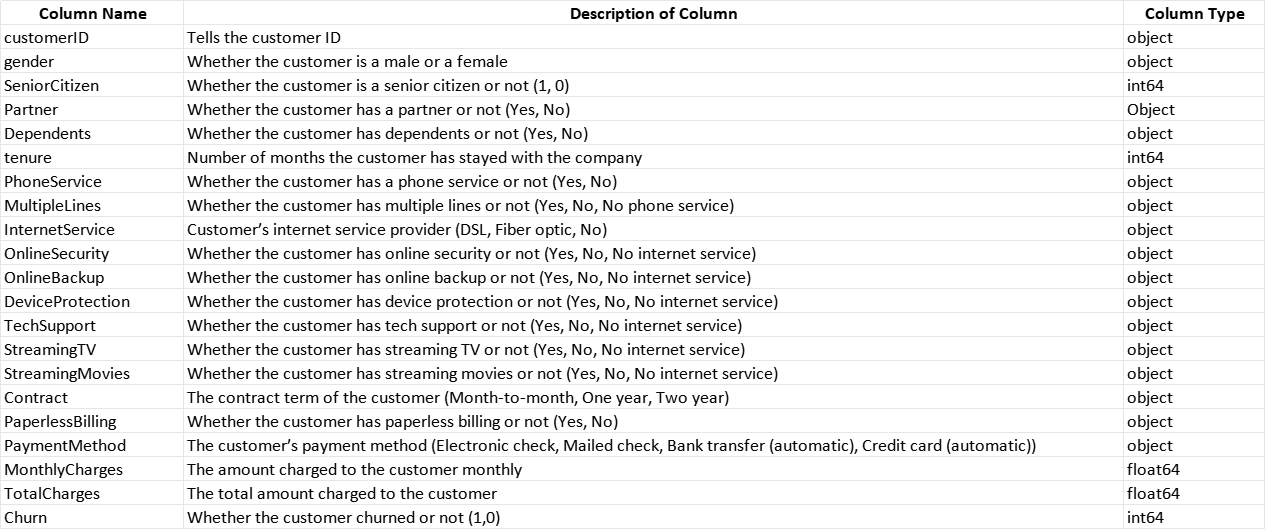

data manipulation

In [34]:
## finding the total number of male customers
df['gender'].value_counts()


,count
gender,
Male,3555
Female,3488


there are total 3555 male customers

In [35]:
## finding the total number of customers whose internet service is dsl
df['InternetService'].value_counts()

,count
InternetService,
Fiber optic,3096
DSL,2421
No,1526


there are toal 2421 customers whose internet service is dsl

In [36]:
##Extracting all the Female senior citizens whose Payment Method is Mailed check & store the
##result in ‘new_customer’

new_customer = df[(df['gender'] == 'Female') & (df['SeniorCitizen'] == 1) & (df['PaymentMethod'] == 'Mailed check')]
new_customer

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
139,0390-DCFDQ,Female,1,Yes,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,70.45,70.45,Yes
176,2656-FMOKZ,Female,1,No,No,15,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.45,1145.7,Yes
267,3197-ARFOY,Female,1,No,No,19,Yes,No,Fiber optic,Yes,...,No,Yes,Yes,Yes,Month-to-month,Yes,Mailed check,105.00,2007.25,No
451,5760-WRAHC,Female,1,No,No,22,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,Month-to-month,Yes,Mailed check,69.75,1545.4,No
470,4933-IKULF,Female,1,No,No,17,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.65,330.6,No
694,2682-KEVRP,Female,1,No,No,22,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,20.05,417,No
747,3966-HRMZA,Female,1,No,No,3,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,No,Mailed check,75.05,202.9,No
947,9904-EHEVJ,Female,1,Yes,Yes,32,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,No,Month-to-month,Yes,Mailed check,91.35,2896.55,No
1029,4184-TJFAN,Female,1,Yes,Yes,3,Yes,No,Fiber optic,Yes,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,88.30,273.75,Yes
1112,2176-LVPNX,Female,1,No,No,71,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Mailed check,89.85,6293.45,No


In [37]:
##Extracting all those customers whose tenure is less than 10 months or their Total charges is less
##than 500$ & store the result in ‘new_customer’
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)
new_customer = df[(df['tenure'] < 10) | (df['TotalCharges'] < 500)]
new_customer

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7029,2235-DWLJU,Female,1,No,No,6,No,No phone service,DSL,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,44.40,263.05,No
7030,0871-OPBXW,Female,0,No,No,2,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.05,39.25,No
7032,6894-LFHLY,Male,1,No,No,1,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,75.75,75.75,Yes
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No


Data Visualization:


a. Building a pie-chart to show the distribution of customers would be churning out

b. Building a bar-plot to show the distribution of ‘Internet Service’


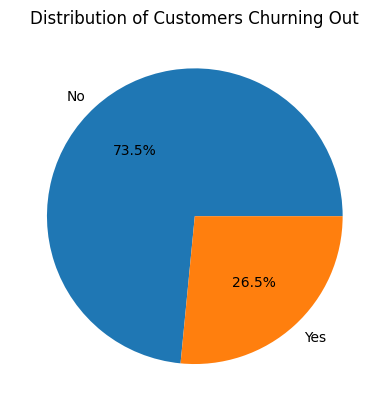

In [38]:
plt.pie(df['Churn'].value_counts(), labels=df['Churn'].unique(), autopct='%1.1f%%')
plt.title('Distribution of Customers Churning Out')
plt.show()

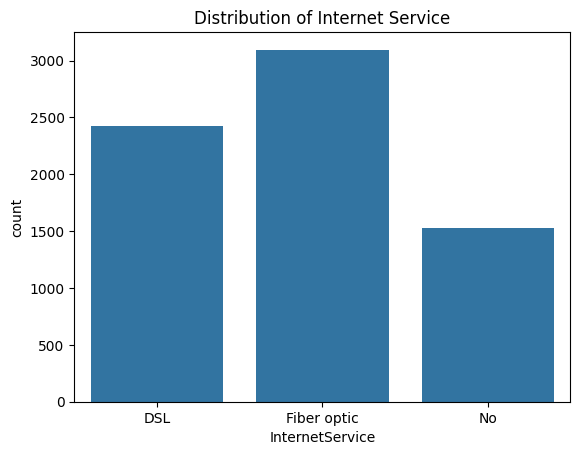

In [39]:
sns.countplot(x='InternetService', data=df)
plt.title('Distribution of Internet Service')
plt.show()

C) Model Building:
a. Build a sequential model using Keras, to find out if the customerwouldchurn or not, using
‘tenure’ as the feature and ‘Churn’ as the dependent/target column:


i. The visible/input layer should have 12 nodes with ‘Relu’ as activation function.


ii. This model would have 1 hidden layer with 8 nodes and ‘Relu’ as activation function


iii. Use ‘Adam’ as the optimization algorithm


iv. Fit the model on the train set, with number of epochs to be 150


v. Predict the values on the test set and build a confusion matrix


vi. Plot the ‘Accuracy vs Epochs’ graph

In [40]:
# Importing Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Convert Churn to numerical values
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

# Select feature and target
X = df[['tenure']]
y = df['Churn']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Building Sequential Model
model = Sequential()

# Input Layer (12 nodes)
model.add(Dense(units=12, activation='relu',input_dim=1))

# Hidden Layer (8 nodes)
model.add(Dense(units=8,activation='relu'))

# Output Layer
model.add(Dense(units=1,activation='sigmoid'))

# Compiling Model
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

# Train Model
history = model.fit(X_train,y_train,epochs=150,validation_split=0.2,verbose=1)

# Predictions
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6974 - loss: 0.6546 - val_accuracy: 0.7507 - val_loss: 0.5733
Epoch 2/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7304 - loss: 0.5412 - val_accuracy: 0.7507 - val_loss: 0.5003
Epoch 3/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7304 - loss: 0.5219 - val_accuracy: 0.7507 - val_loss: 0.4967
Epoch 4/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7304 - loss: 0.5200 - val_accuracy: 0.7507 - val_loss: 0.4958
Epoch 5/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7304 - loss: 0.5191 - val_accuracy: 0.7507 - val_loss: 0.4949
Epoch 6/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7304 - loss: 0.5183 - val_accuracy: 0.7507 - val_loss: 0.4941
Epoch 7/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7304 - loss: 0.5176 - val_accuracy: 0.7507 - val_loss: 0.4940
Epoch 8/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7342 - loss: 0.5174 - val_accuracy: 0.7471

explanation

Sequential() creates a feed-forward neural network.

Input layer contains 12 neurons with ReLU activation.

Hidden layer contains 8 neurons with ReLU activation.

Output layer contains 1 neuron with Sigmoid activation because the problem is binary classification (Churn: Yes/No).

Adam optimizer is used for faster convergence.

Model is trained for 150 epochs.

Predictions are converted into 0 and 1 using a threshold of 0.5.

A confusion matrix is generated to evaluate classification performance.

Accuracy vs Epochs graph helps visualize the learning progress of the model.

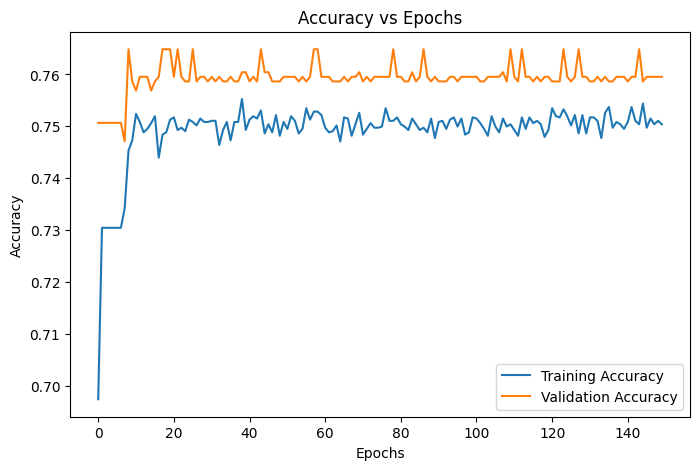

In [41]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],label='Training Accuracy')

plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()

plt.show()

 Build the 2nd model using same target and feature variables:


i. Add a drop-out layer after the input layer with drop-out value of 0.3

ii. Add a drop-out layer after the hidden layer with drop-out value of 0.2

iii. Predict the values on the test set and build a confusion matrix

iv. Plot the ‘Accuracy vs Epochs’ graoh

In [42]:

# Building Model
model2 = Sequential()

# Input Layer
model2.add(Dense(units=12,
                 activation='relu',
                 input_dim=1))

# Dropout Layer (0.3)
model2.add(Dropout(0.3))

# Hidden Layer
model2.add(Dense(units=8,activation='relu'))

# Dropout Layer (0.2)
model2.add(Dropout(0.2))

# Output Layer
model2.add(Dense(units=1,activation='sigmoid'))

# Compiling  Model
model2.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

# Train Model
history2 = model2.fit(X_train,y_train,epochs=150,validation_split=0.2,verbose=1)

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7093 - loss: 0.6452 - val_accuracy: 0.7507 - val_loss: 0.5568
Epoch 2/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7286 - loss: 0.5544 - val_accuracy: 0.7507 - val_loss: 0.5034
Epoch 3/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7353 - loss: 0.5397 - val_accuracy: 0.7507 - val_loss: 0.4996
Epoch 4/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7284 - loss: 0.5414 - val_accuracy: 0.7507 - val_loss: 0.4980
Epoch 5/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7355 - loss: 0.5363 - val_accuracy: 0.7507 - val_loss: 0.4968
Epoch 6/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7324 - loss: 0.5349 - val_accuracy: 0.7507 - val_loss: 0.4964
Epoch 7/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7384 - loss: 0.5308 - val_accuracy: 0.7507 - val_loss: 0.4963
Epoch 8/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7373 - loss: 0.5280 - val_accuracy: 0.7507

In [43]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Predict
y_pred2 = model2.predict(X_test)
y_pred2 = (y_pred2 > 0.5)

# Confusion Matrix
cm2 = confusion_matrix(y_test, y_pred2)

print("Confusion Matrix:")
print(cm2)

# Accuracy
acc2 = accuracy_score(y_test, y_pred2)

print("Accuracy:", acc2)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Confusion Matrix:
[[982  54]
 [289  84]]
Accuracy: 0.7565649396735273


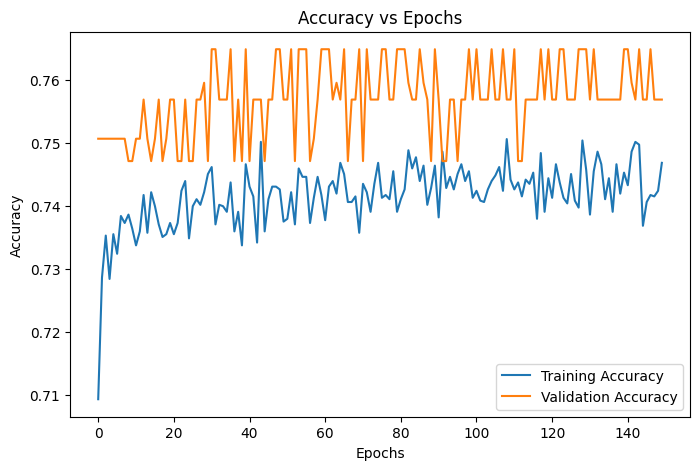

In [44]:

plt.figure(figsize=(8,5))

plt.plot(history2.history['accuracy'],label='Training Accuracy')

plt.plot(history2.history['val_accuracy'],label='Validation Accuracy')

plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

dropout is a regularization technique used to reduce overfitting.
During training, some neurons are randomly ignored (dropped).
This prevents the model from relying too much on specific neurons.



In this model:

After the input layer → Dropout(0.3) → 30% neurons dropped.

After the hidden layer → Dropout(0.2) → 20% neurons dropped.

Optimizer = Adam.

Epochs = 150.

Output layer uses Sigmoid for binary classification (Churn Yes/No).

Building the 3rd model using ‘Tenure’, ’Monthly Charges’ & ‘Total Charges’ as the features and

‘Churn’ as the dependent/target column:

i. The visible/input layer should have 12 nodes with ‘Relu’ as activation function.

ii. This model would have 1 hidden layer with 8 nodes and ‘Relu’ as activation function

iii. Use ‘Adam’ as the optimization algorithm

iv. Fit the model on the train set, with number of epochs to be 150

v. Predict the values on the test set and build a confusion matrix

vi. Plot the ‘Accuracy vs Epochs’ graph

In [45]:


# Load Dataset
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Remove missing values
df.dropna(inplace=True)

# Convert Churn to numeric
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

# Features and Target
X = df[['tenure', 'MonthlyCharges', 'TotalCharges']]
y = df['Churn']

In [46]:


X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.2,random_state=42)

# Feature Scaling
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [47]:

model3 = Sequential()

# Input Layer
model3.add(Dense(units=12,activation='relu',input_dim=3))

# Hidden Layer
model3.add(Dense(units=8,activation='relu'))

# Output Layer
model3.add(Dense(units=1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [48]:
model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [49]:
history3 = model3.fit(X_train,y_train,epochs=150,validation_split=0.2,verbose=1)

Epoch 1/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7313 - loss: 0.5692 - val_accuracy: 0.7218 - val_loss: 0.5079
Epoch 2/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7373 - loss: 0.4849 - val_accuracy: 0.7227 - val_loss: 0.4769
Epoch 3/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7691 - loss: 0.4682 - val_accuracy: 0.7902 - val_loss: 0.4595
Epoch 4/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7742 - loss: 0.4610 - val_accuracy: 0.7902 - val_loss: 0.4543
Epoch 5/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7773 - loss: 0.4577 - val_accuracy: 0.7893 - val_loss: 0.4496
Epoch 6/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7796 - loss: 0.4557 - val_accuracy: 0.7964 - val_loss: 0.4471
Epoch 7/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7800 - loss: 0.4540 - val_accuracy: 0.7911 - val_loss: 0.4446
Epoch 8/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7813 - loss: 0.4533 - val_accu

In [50]:
y_pred3 = model3.predict(X_test)
y_pred3 = (y_pred3 > 0.5)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [51]:

cm3 = confusion_matrix(y_test, y_pred3)

print("Confusion Matrix:")
print(cm3)

accuracy = accuracy_score(y_test, y_pred3)

print("Accuracy:", accuracy)

Confusion Matrix:
[[943  90]
 [209 165]]
Accuracy: 0.7874911158493249


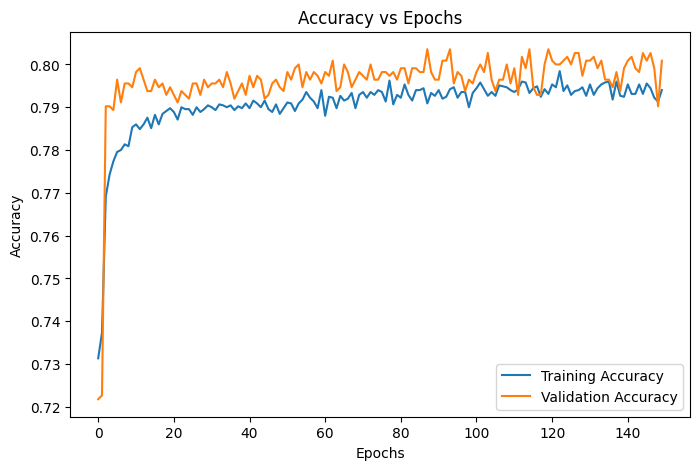

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history3.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history3.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

This model uses three customer-related features (tenure, MonthlyCharges, and TotalCharges) to predict customer churn. The ANN consists of an input layer with 12 neurons using ReLU activation, one hidden layer with 8 neurons using ReLU activation, and an output layer with a single neuron using Sigmoid activation for binary classification. The model is trained using the Adam optimizer for 150 epochs. After training, predictions are made on the test dataset, a confusion matrix is generated to evaluate performance, and the Accuracy vs Epochs graph is plotted to visualize the learning process.